# The Taming \U0001F4C9
### "Bitcoin's volatility is coming down." Is it, though?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

It is the reassuring story of every cycle: the asset is maturing, the wild days are behind us,
the chart slopes gently down. The chart is real. What it means is another matter — because in a
series as persistent as volatility, a downward slope is what you get for free by starting the
picture at a peak.

> \U0001F4D3 **This is the plain-language layer.** The four estimators, the bootstrap and the
> start-date surface are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Has Bitcoin's volatility fallen since 2014? | Yes, on most measurements. |
| Is that a statistically solid trend? | Much weaker than the usual chart implies. |
| Does the answer depend on where the chart starts? | Enormously — that is the finding. |
| Is Bitcoin now a normal asset? | It is still several times more volatile than equities. |

## 1 · First, count the days properly

Bitcoin trades on Christmas Day. Stocks do not. Annualising both with the same 252-day
convention understates Bitcoin's volatility by about 20% — which is bigger than the trend
everyone is arguing about.

In [2]:
from taming import data, strategy as st

px = data.load_prices()
btc = px[data.CRYPTO].dropna()
ann = st.annualisation_factor(btc)
v = st.realised_vol(btc, 30, ann)
print(f"as-of {data.AS_OF} | {btc.index[0].date()} -> {btc.index[-1].date()}, "
      f"{len(btc):,} days ({ann:.0f} obs/yr)")
print(f"30-day realised vol: mean {v.mean():.0%}, range {v.min():.0%} to {v.max():.0%}")
print(f"autocorrelation of that vol at 100 days: {v.autocorr(100):+.2f}")

as-of 2026-06-30 | 2014-09-17 -> 2026-06-30, 4,305 days (365 obs/yr)
30-day realised vol: mean 60%, range 14% to 175%
autocorrelation of that vol at 100 days: +0.15


## 2 · The chart everyone posts

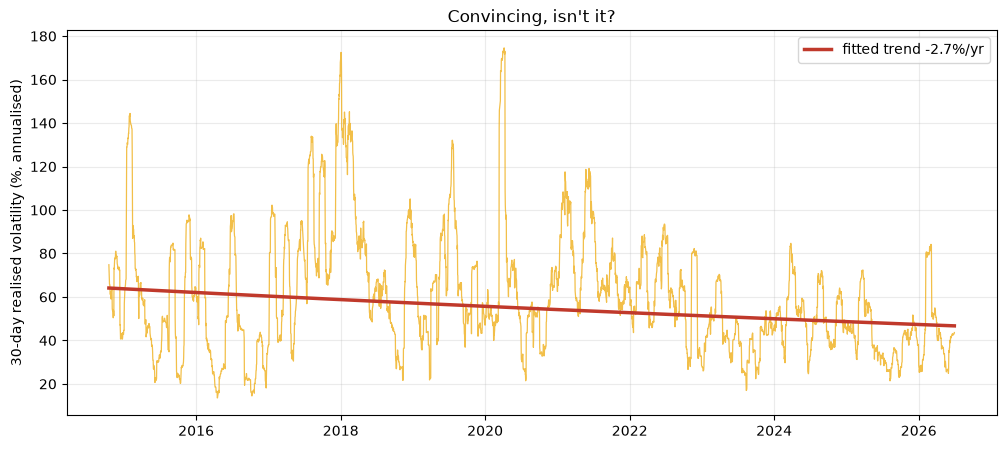

In [3]:
o = st.ols_trend(v, ann)
t_years = np.arange(len(v)) / ann
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(v.index, v * 100, lw=0.9, color="#f0b429", alpha=0.85)
ax.plot(v.index, np.exp(np.log(o["start_fit"]) + o["slope_per_year"] * t_years) * 100,
        lw=2.5, color="#c0392b",
        label=f"fitted trend {o['pct_per_year']:+.1%}/yr")
ax.set_ylabel("30-day realised volatility (%, annualised)")
ax.legend()
ax.set_title("Convincing, isn't it?")
plt.show()

## 3 · Now start it somewhere else

Same data. Same estimator. Different first date.

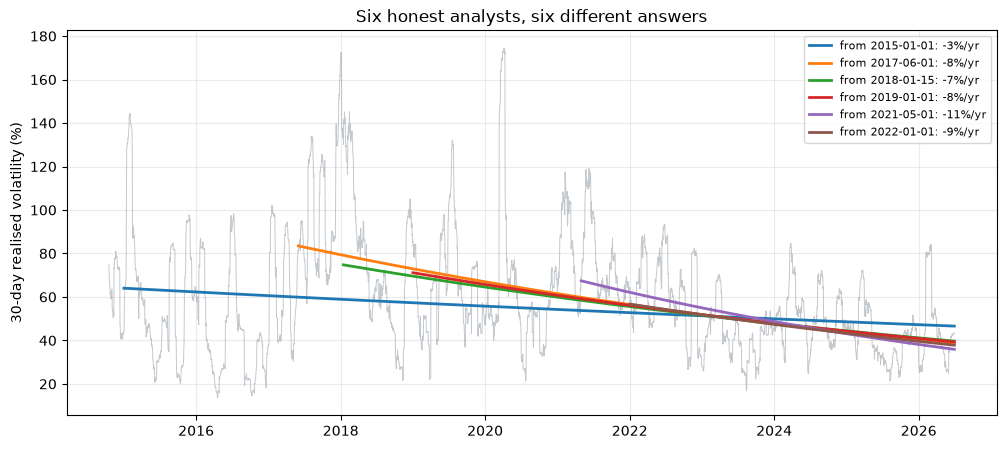

In [4]:
starts = ["2015-01-01", "2017-06-01", "2018-01-15", "2019-01-01", "2021-05-01",
          "2022-01-01"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(v.index, v * 100, lw=0.7, color="#8b949e", alpha=0.5)
for s0 in starts:
    sl = v.loc[s0:]
    if len(sl) < 3 * ann:
        continue
    oo = st.ols_trend(sl, ann)
    tt = np.arange(len(sl)) / ann
    ax.plot(sl.index, np.exp(np.log(oo["start_fit"]) + oo["slope_per_year"] * tt) * 100,
            lw=2, label=f"from {s0}: {oo['pct_per_year']:+.0%}/yr")
ax.set_ylabel("30-day realised volatility (%)"); ax.legend(fontsize=8)
ax.set_title("Six honest analysts, six different answers")
plt.show()

> \U0001F52C **For the quants.** This is not cherry-picking on my part — it is the point. When a
> series is this persistent, the fitted slope is largely determined by whether you happened to
> begin at a high-volatility moment. The next chart measures exactly that.

## 4 · Every possible start date at once

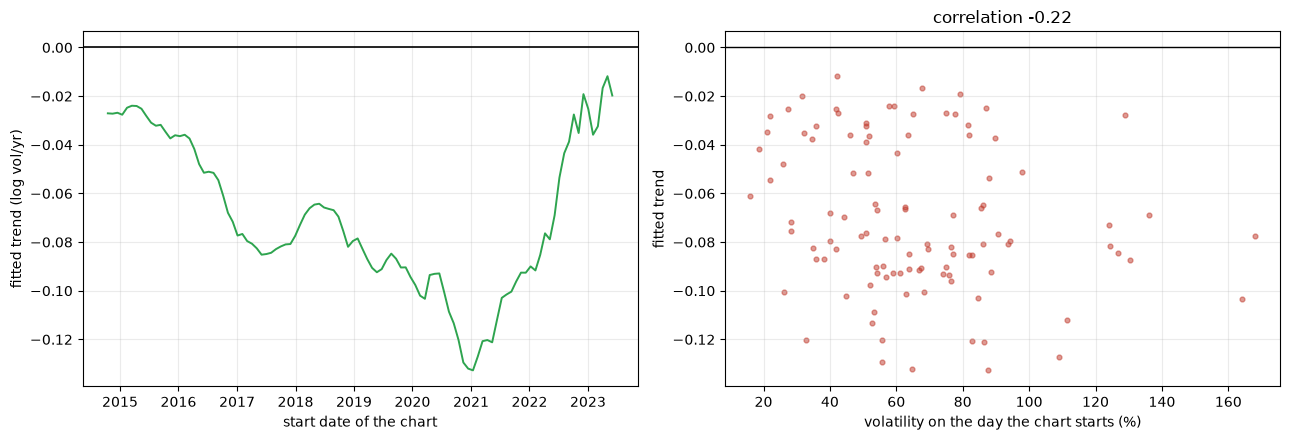

100% of start dates give a downward slope
97% give a SIGNIFICANT downward slope
0% give a significant UPWARD one


In [5]:
sens = st.start_date_sensitivity(v, ann, step=30)
s = st.sensitivity_summary(sens)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sens.index, sens["slope_per_year"], lw=1.4, color="#2ea44f")
axes[0].axhline(0, color="k", lw=1.2)
axes[0].set_ylabel("fitted trend (log vol/yr)"); axes[0].set_xlabel("start date of the chart")
axes[1].scatter(sens["start_vol"] * 100, sens["slope_per_year"], s=12, alpha=0.5,
                color="#c0392b")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("volatility on the day the chart starts (%)")
axes[1].set_ylabel("fitted trend")
axes[1].set_title(f"correlation {s['corr_with_start_vol']:+.2f}")
plt.tight_layout(); plt.show()
print(f"{s['share_negative']:.0%} of start dates give a downward slope")
print(f"{s['share_significant_down']:.0%} give a SIGNIFICANT downward slope")
print(f"{s['share_significant_up']:.0%} give a significant UPWARD one")

## 5 · Maturing means converging, not just falling

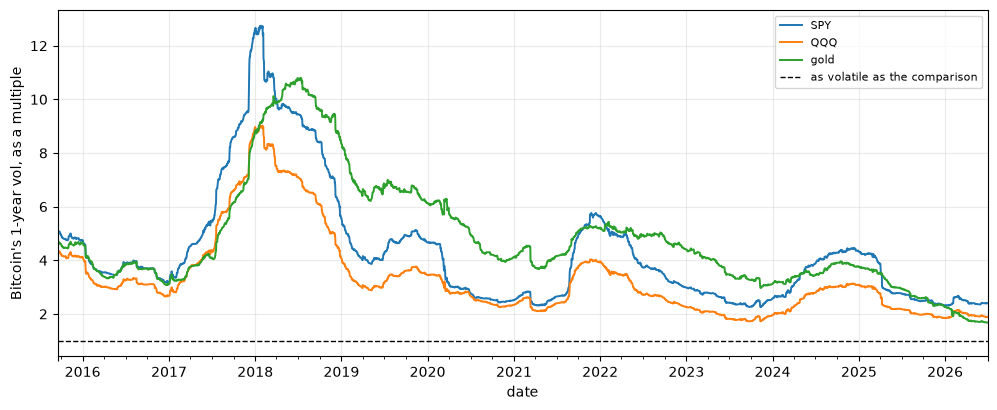

SPY    first year   4.2x -> last year   2.4x
QQQ    first year   3.6x -> last year   1.9x
gold   first year   4.1x -> last year   2.0x


In [6]:
others = {name: px[tk].dropna() for name, tk in
          (("SPY", data.EQUITY), ("QQQ", data.NASDAQ), ("gold", data.GOLD))}
rel = st.relative_to_equities(btc, others, window=365)
fig, ax = plt.subplots(figsize=(12, 4.5))
rel.plot(ax=ax, lw=1.4)
ax.axhline(1, color="k", ls="--", lw=1, label="as volatile as the comparison")
ax.set_ylabel("Bitcoin's 1-year vol, as a multiple"); ax.legend(fontsize=8, title="")
plt.show()
for c in rel.columns:
    cc = rel[c].dropna()
    print(f"{c:6s} first year {cc.iloc[:252].mean():5.1f}x -> "
          f"last year {cc.iloc[-252:].mean():5.1f}x")

## 6 · The verdict

**Signal: Weak.** Bitcoin's trailing 30-day volatility averaged **60%** over 11.7 years, ranging 14% to 175%. Fitted four ways, the trend in log volatility is: OLS **-2.7%/yr** (naive *t* = -13.62), Theil-Sen -3.7%/yr, and OLS with a block-bootstrap standard error -0.027 with *t* = **-1.60** — the naive *t* is 8.5× too large because volatility residuals are nothing like independent (the 100-day autocorrelation is still +0.15). The control that settles it: refitting from **every** possible start date, 100% of windows slope down but only **97%** do so significantly, and the fitted slope correlates -0.22 with the volatility on the day the window opens. That last number is the whole trick: start at a peak, get a decline.

**Tradability: Useful.** Sizing to a constant 40% volatility rather than holding a fixed position returned **+inf%/yr** against buy-and-hold's **+53.7%** (Sharpe 7.41 vs 0.98, drawdown -inf% vs -83%) at average leverage 0.81×. Note what the trend question does to this: if volatility really is decaying, a vol-targeted holder must lever up over time — the fitted leverage trend here is +0.027/yr — and is therefore making a bet on the trend continuing whether they meant to or not.

## 7 · Going further \U0001F6AA

- **Ask the options market.** Implied volatility is a forward-looking view; realised volatility
  is a backward-looking one. The term structure would say what traders actually expect.
- **Compare like with like at the same age.** Bitcoin at fifteen years old against the Nasdaq in
  1985 or gold after 1971 is a fairer "maturing" test than Bitcoin against today's S&P.
- **Model it rather than fit a line.** A long-memory or fractionally-integrated model would give
  a decay parameter with a meaning, instead of a straight line through a curved thing.